# Init

In [1]:
%reload_ext autoreload
%autoreload 2

%config InlineBackend.figure_format = 'retina' # High-resolution plot outputs for Retina laptops

In [2]:
# Batteries
from datetime import datetime, timedelta

# Externals
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model

# Experiment

## Germany

In [3]:
X = np.array([[1], [2], [3], [4], [5], [6]])
y = np.array([6.2, 7.2, 8.4, 12.1, 15.3, 16.5])
X_test = np.array([[7], [8], [9]])

In [4]:
regr = linear_model.LinearRegression()

In [5]:
regr.fit(X, y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [6]:
y_pred = regr.predict(X_test)
y_pred

array([18.9       , 21.17142857, 23.44285714])

In [7]:
y_approximate = regr.predict(X)

In [8]:
# The coefficients
print('Coefficients: \n', regr.coef_)

Coefficients: 
 [2.27142857]


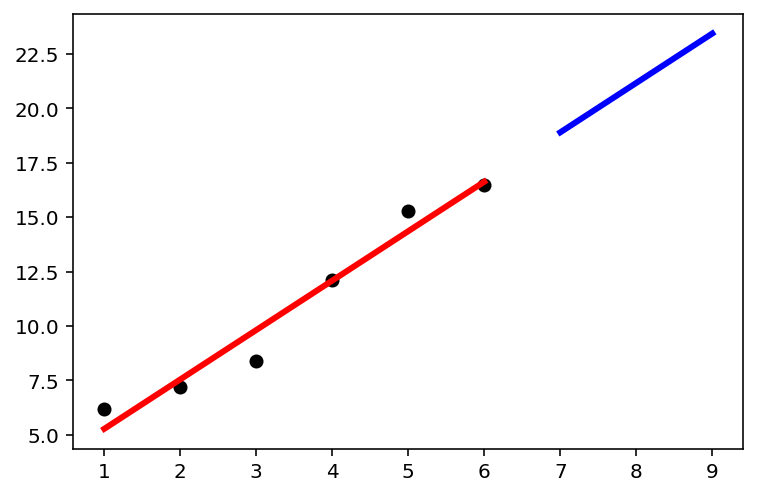

In [9]:
# Plot outputs
plt.scatter(X, y, color='black')
plt.plot(X_test, y_pred, color='blue', linewidth=3)
plt.plot(X, y_approximate, color='red', linewidth=3)
plt.show()

# Func

## `predict_lr`

In [17]:
def predict_lr(country, X, y, X_pred, x_days):
    # Step: Predict
    regr = linear_model.LinearRegression()
    regr.fit(X, y)
    y_pred = regr.predict(X_pred)
    y_approximate = regr.predict(X)
    coef = regr.coef_
    
    # Step: Plot
    fig, ax = plt.subplots()
    ax.scatter(X, y, color='black')
    ax.plot(X, y_approximate, color='green', linewidth=3)
    
    ax.scatter(X_pred, y_pred, color='red')
    ax.plot(X_pred, y_pred, color='blue', linewidth=3)

    # Step: Notes
    nums = "Predict: " + ", ".join([str(round(x, 1)) for x in y_pred])
    xlabels = [x.strftime('%m.%d') for x in x_days]
    end = (-1) * len(X_pred)
    dates = ", ".join(xlabels[end:])
    title = f'{country}, {nums}\n@ {dates}\nK = {coef}'
    ax.set_title(title)
    plt.xticks(ticks=range(1, len(x_days)+1), labels=xlabels)

    # Step: Show
    fig.tight_layout()
    plt.show()

# Flow

## x values

In [11]:
X = np.array([[1], [2], [3], [4], [5], [6]])
X_pred = np.array([[7], [8], [9]])

dt0 = datetime(2020, 7, 17)
x_days = [dt0 + timedelta(days=7)*x for x in range(len(X)+len(X_pred))]

## Germany

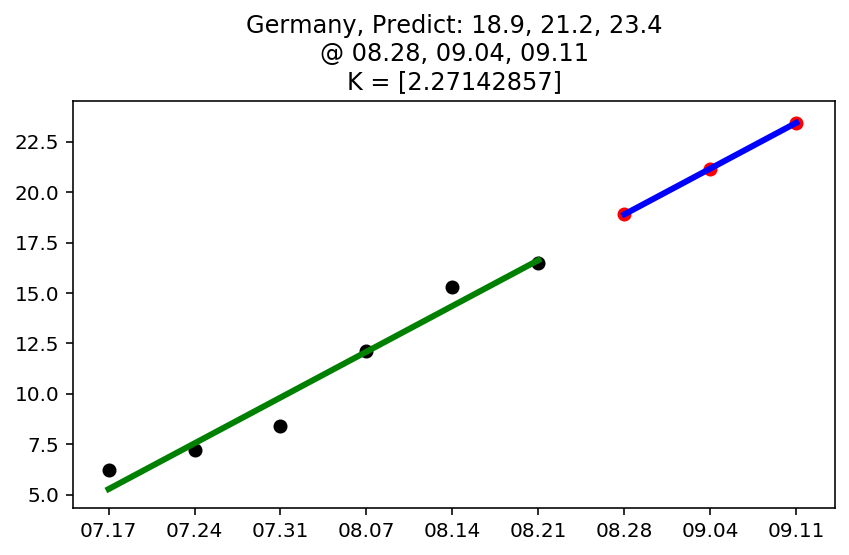

In [19]:
country = 'Germany'
y = np.array([6.2, 7.2, 8.4, 12.1, 15.3, 16.5])
predict_lr(country, X, y, X_test, x_days)

## Latvia

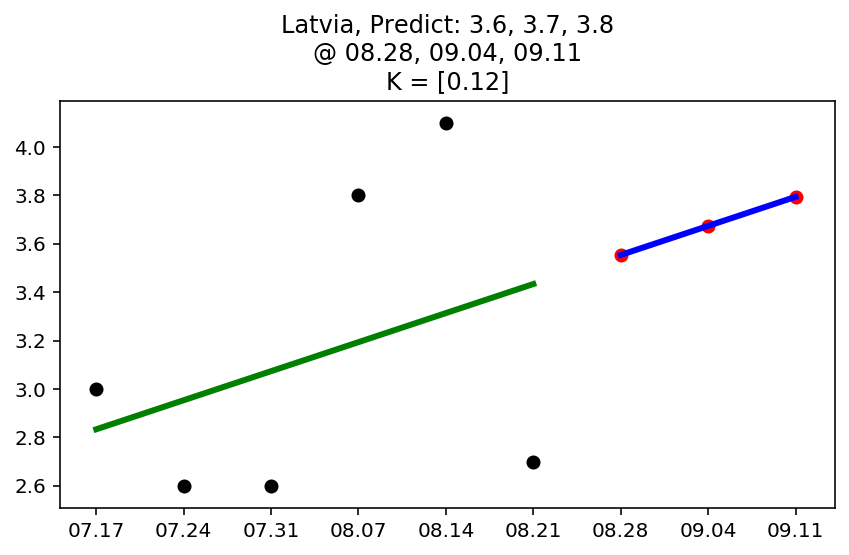

In [20]:
country = 'Latvia'
y = np.array([3.0, 2.6, 2.6, 3.8, 4.1, 2.7])
predict_lr(country, X, y, X_test, x_days)

## Norway

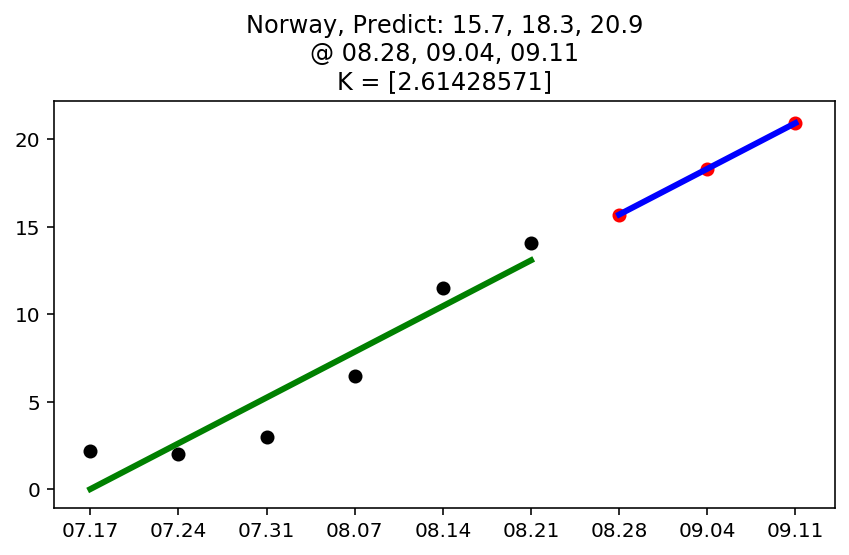

In [21]:
country = 'Norway'
y = np.array([2.2, 2.0, 3.0, 6.5, 11.5, 14.1])
predict_lr(country, X, y, X_test, x_days)

## UK

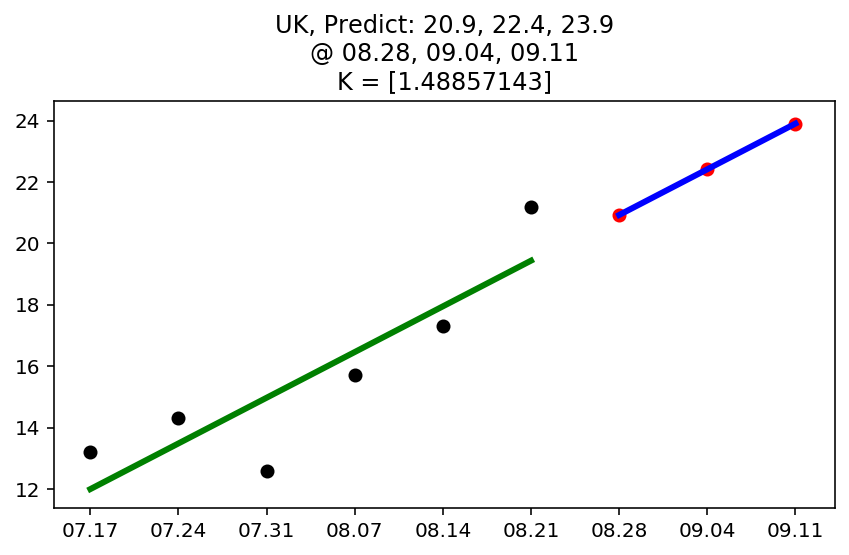

In [22]:
country = 'UK'
y = np.array([13.2, 14.3, 12.6, 15.7, 17.3, 21.2])
predict_lr(country, X, y, X_test, x_days)

## France

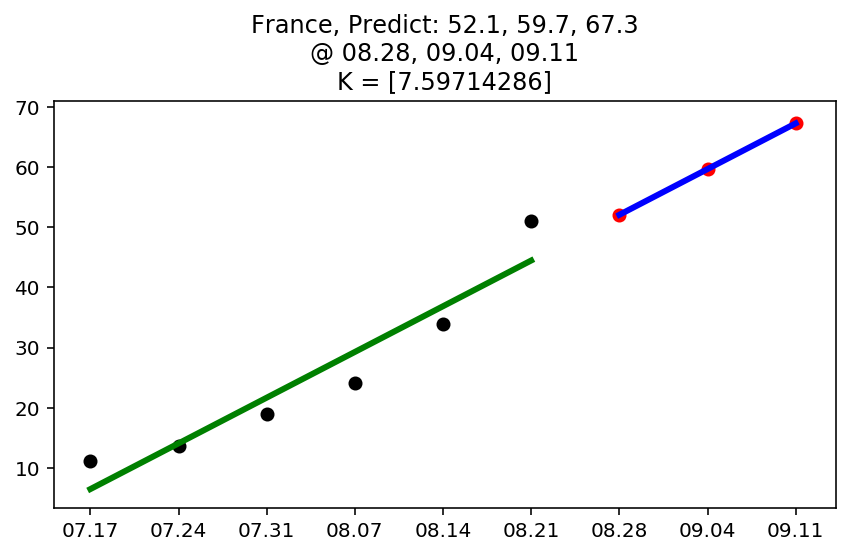

In [23]:
country = 'France'
y = np.array([11.1, 13.6, 19.0, 24.2, 34.0, 51.0])
predict_lr(country, X, y, X_test, x_days)

## Cyprus

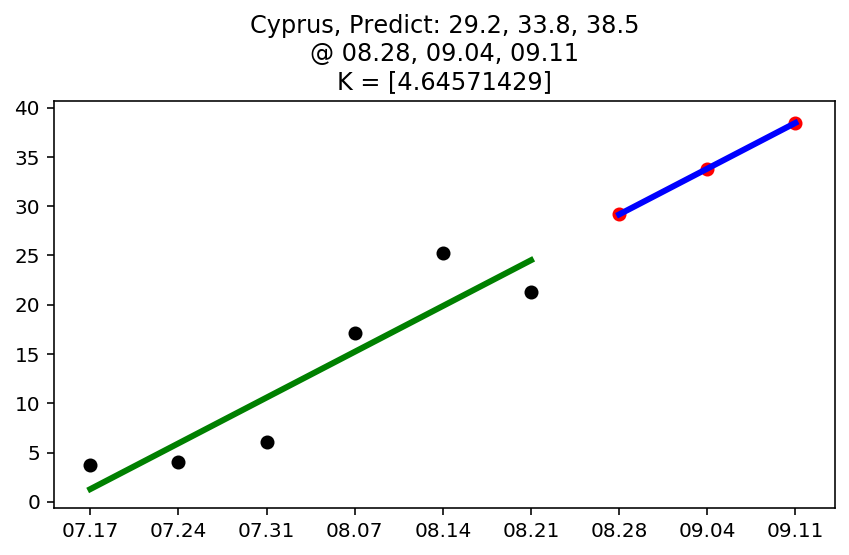

In [24]:
country = 'Cyprus'
y = np.array([3.7, 4.0, 6.1, 17.1, 25.2, 21.3])
predict_lr(country, X, y, X_test, x_days)